# Complete ML pipeline

# Complete machine learning pipeline

* unify the plot style 
* read and prepare data from downloaded csv from Kaggle
* fetch and prepare weather data from open-meteo API
* combine and create features for energy and weather data
* train and test data split - time series split
* train and evaluate model
* BayesSearchCV
* save best model 
* plot learn curve


* refactor the steps to functions in fetch_prepare_data.py and train_model_predict.py

In [ ]:
import sys
import os

# Add the src directory to the system path to allow importing custom modules
sys.path.insert(0, os.path.abspath('../src'))

import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2

import numpy as np
import pickle
import pandas as pd

from fetch_prepare_data import *
from train_model_predict import *

# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})


In [ ]:
from fetch_prepare_data import *
from train_model_predict import *

df_for_modeling = prepare_data_for_modeling()
#print(df_for_modeling.shape)
#display(df_for_modeling.head(3))    

df_for_modeling.to_pickle('../data/processed/energy_weather_data_for_modeling.pkl')

In [16]:
# tune LightGBM with Bayesian optimization using Optuna
# tune without preprocessor - tree models are not affected by scaling, so we can skip the preprocessor for tuning
from lightgbm import LGBMRegressor
import pandas as pd
from fetch_prepare_data import *
from train_model_predict import *

#with open('../data/processed/energy_weather_data_for_modeling.pkl', 'rb') as f:
#    df_for_modeling = pickle.load(f)
#df_for_modeling = prepare_data_for_modeling()

features_train, target_train, features_test, target_test = train_test_split_by_date(df_for_modeling, 
                                                                                    date_column='time',
                                                                                    target_column='EnergyDemand', 
                                                                                    split_date='2025-01-01')

# define continuous parameter grid for LightGBM
param_lgbm_continuous = { 
    'n_estimators': (50, 500),  # range for n_estimators
    'learning_rate': (0.01, 0.3),  # range for learning_rate
    'max_depth': (3, 15)  # range for max_depth
}

model_lgbm =LGBMRegressor(random_state=42, force_col_wise=True)
best_model_lgbm, best_params_lgbm = tune_model_bayesian(
    model_pipeline=model_lgbm, 
    in_param_bayes=param_lgbm_continuous,
    in_features_train=features_train, 
    in_target_train=target_train)
print(f"Best hyperparameters: {best_params_lgbm}")

print()

prediction_lgbm = best_model_lgbm.predict(features_test)

print_scores('LightGBM', target_test, prediction_lgbm)  

save_model_to_pickle(best_model_lgbm, '../models/best_lgbm_model_bayesian.pkl')


[LightGBM] [Info] Total Bins 3900
[LightGBM] [Info] Number of data points in the train set: 52416, number of used features: 26
[LightGBM] [Info] Start training from score 54977.463113
Best hyperparameters: OrderedDict({'learning_rate': 0.037736567991071564, 'max_depth': 12, 'n_estimators': 500})

-------------------- scoring --------------------
model                  MAE       RMSE       R²
LightGBM            1236.30    1613.02     0.97


In [17]:
# tune XGBoost hyperparameters using Bayesian optimization with Optuna
from xgboost import XGBRegressor
from fetch_prepare_data import *
from train_model_predict import *

#with open('../data/processed/energy_weather_data_for_modeling.pkl', 'rb') as f:
#    df_for_modeling = pickle.load(f)
#features_train, target_train, features_test, target_test = train_test_split_by_date(df_for_modeling, 
#                                                                                    date_column='time',
#                                                                                    target_column='EnergyDemand', 
#                                                                                    split_date='2025-01-01')

# define continuous parameter grid for XGBoost
param_xgb_continuous = {
    'n_estimators': (50, 500),  # range for n_estimators
    'max_depth': (3, 15),       # range for max_depth
    'learning_rate': (0.01, 0.3), # range for learning_rate
    'subsample': (0.5, 1.0),    # range for subsample
    'colsample_bytree': (0.5, 1.0), # range for colsample_bytree
    # max_features is categorical
    'max_features': [1.0, 'sqrt', 'log2'],
}

model_xgb = XGBRegressor(random_state=42)
best_model_xgb, best_params_xgb = tune_model_bayesian(
    model_pipeline=model_xgb,
    in_param_bayes=param_xgb_continuous,
    in_features_train=features_train,   
    in_target_train=target_train
)
print(f"Best hyperparameters for XGBoost: {best_params_xgb}")

y_pred_xgb = best_model_xgb.predict(features_test)

print_scores('XGBoost', target_test, y_pred_xgb)

save_model_to_pickle(best_model_xgb, '../models/best_xgb_model_bayesian.pkl')

Best hyperparameters for XGBoost: OrderedDict({'colsample_bytree': 0.7409156479174064, 'learning_rate': 0.035118903163658975, 'max_depth': 8, 'max_features': 1.0, 'n_estimators': 500, 'subsample': 0.848828736860538})
-------------------- scoring --------------------
model                  MAE       RMSE       R²
XGBoost             1156.96    1500.81     0.97


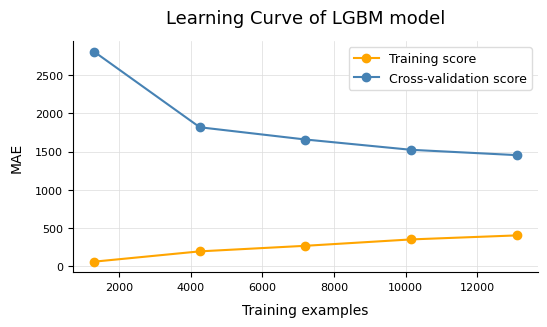

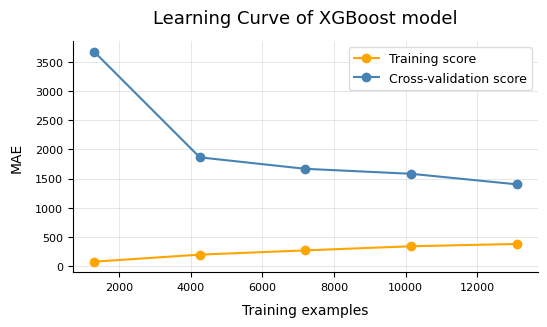

In [ ]:
# plot learning curve for LGBM and XGBoost models
plot_learning_curve(best_model_lgbm, 'LGBM model', features_train, target_train)
plot_learning_curve(best_model_xgb, 'XGBoost model', features_train, target_train)